# 🧪 A/B Testing — Analisis Kandungan Sodium
# Proyek GiziKu — Coding Camp 2026 | CC26-PSU033
# Data Scientist: Eka Sriyulianti Makami


##1. Pendahuluan

Dataset ini merupakan **dataset final hasil proses EDA** (Gathering, Assessing, Cleaning) yang berisi informasi kandungan gizi berbagai makanan untuk anak. Dataset mencakup 10 kategori makanan dengan 16 fitur nutrisi, termasuk Kalori, Lemak, Protein, Karbohidrat, Serat, Gula, **Sodium**, dan Kalium.

Notebook ini berfokus pada pengujian statistik menggunakan pendekatan **A/B Testing** untuk membandingkan kandungan sodium antara dua kelompok makanan yang berbeda secara karakteristik pengolahan.

##2. Latar Belakang Eksperimen

Sodium (natrium) merupakan mineral penting, namun **konsumsi sodium berlebih pada anak** dapat menyebabkan hipertensi dini, gangguan ginjal, dan masalah kardiovaskular jangka panjang. WHO merekomendasikan asupan sodium untuk anak di bawah **1.200–2.300 mg/hari** tergantung usia.

Salah satu faktor utama tingginya konsumsi sodium adalah **jenis makanan** yang dikonsumsi:

- **Makanan Segar** (buah, sayur) cenderung rendah sodium karena minim proses pengolahan industri.
- **Makanan Olahan & Snack** (sup kemasan, keripik, sosis, roti) umumnya menggunakan garam/sodium sebagai pengawet dan perasa.

Pembuktian perbedaan ini secara statistik akan memberikan **dasar ilmiah** bagi fitur rekomendasi dan peringatan sodium dalam aplikasi GiziKu.

##3. Tujuan A/B Testing

1. Menguji apakah terdapat **perbedaan signifikan** kandungan sodium antara makanan segar (Buah & Sayur) dan makanan olahan (Snack, Sup, Karbohidrat olahan).
2. Mengukur **besar perbedaan (effect size)** antara kedua kelompok.
3. Menghasilkan **insight berbasis data** untuk mendukung pengembangan fitur peringatan sodium di aplikasi GiziKu.

## ⚠️ Catatan Akademik: Terminologi "A/B Testing"

Istilah **"A/B Testing"** secara teknis merujuk pada **Randomized Controlled Experiment (RCT)** —
di mana unit observasi (pengguna, item) secara **acak** dialokasikan ke kelompok A atau B
untuk mengukur dampak suatu *treatment* atau intervensi.

**Dalam notebook ini**, pembagian kelompok didasarkan pada **karakteristik inheren** item makanan
(kategori segar vs. olahan), **bukan randomisasi**. Secara metodologis, ini lebih tepat
disebut **Two-Sample Hypothesis Testing** atau **Comparative Observational Study**.

> Penggunaan istilah "A/B Testing" di sini merupakan **konvensi informal** yang umum digunakan
> dalam konteks data analitik bisnis untuk menggambarkan perbandingan dua kelompok secara umum.
> Hal ini tidak mempengaruhi validitas pengujian statistik yang dilakukan.

**Implikasi penting:**
- Hasil tidak dapat diinterpretasikan sebagai **hubungan kausal**.
- Validitas internal lebih terbatas dibanding RCT sejati.
- Kesimpulan bersifat **asosiatif**, bukan kausal.


## 4. Hipotesis

**H₀ (Null Hypothesis):**  
> Tidak terdapat perbedaan yang signifikan antara rata-rata kandungan sodium pada makanan segar (Buah & Sayur) dibandingkan makanan olahan (Snack, Sup, Karbohidrat).

**H₁ (Alternative Hypothesis):**  
> Kandungan sodium pada makanan olahan (Snack, Sup, Karbohidrat) **secara signifikan lebih tinggi** dibandingkan makanan segar (Buah & Sayur).

**Tingkat Signifikansi:** α = 0.05  
**Jenis Uji:** One-tailed (makanan olahan > makanan segar)


## 5. Import Library & Load Dataset

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Load dataset dari URL GitHub
df = pd.read_csv('https://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/EDA_Data_Makanan_Anak(revisi).csv')


## 6. Analisis Struktur Dataset

In [3]:
# Tampilkan 5 baris pertama
print('📋 Preview Dataset (5 baris pertama):')
df.head()

📋 Preview Dataset (5 baris pertama):


,Nama,Kategori,Jumlah Porsi,Takaran Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
0,Alpukat,Buah Buahan,100,gram (g),160.0,14.66,2.126,1.816,9.799,0.0,2.00,8.53,6.7,0.66,7.0,485.0
1,Guacamole,Buah Buahan,1,sdm,23.0,2.08,0.302,0.258,1.393,0.0,0.29,1.24,1.0,0.10,22.0,69.0
2,Guacamole dengan Tomat,Buah Buahan,100,gram (g),116.0,9.94,1.446,1.258,6.625,0.0,1.62,7.64,4.9,1.37,201.0,393.0
3,Guacamole dengan Tomat dan Cabe Paprika,Buah Buahan,1,mangkok,266.0,22.72,3.304,2.882,15.129,0.0,3.77,17.75,11.4,3.31,459.0,913.0
4,Buah Anggur,Buah Buahan,1,tanpa biji,3.0,0.01,0.003,0.002,0.000,0.0,0.04,0.90,0.0,0.77,0.0,10.0


In [4]:
# Informasi tipe data dan missing values
print('📊 Informasi Dataset:')
print(df.info())

📊 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nama                         392 non-null    object 
 1   Kategori                     392 non-null    object 
 2   Jumlah Porsi                 392 non-null    int64  
 3   Takaran Porsi                392 non-null    object 
 4   Kalori (kal)                 392 non-null    float64
 5   Lemak (g)                    392 non-null    float64
 6   Lemak Jenuh (g)              392 non-null    float64
 7   Lemak Tak Jenuh Ganda (g)    392 non-null    float64
 8   Lemak Tak Jenuh Tunggal (g)  392 non-null    float64
 9   Kolestrol (g)                392 non-null    float64
 10  Protein (g)                  392 non-null    float64
 11  Karbohidrat (g)              392 non-null    float64
 12  Serat (g)                    392 non-null    float64
 13 

In [5]:
# Statistik deskriptif seluruh dataset
print('📈 Statistik Deskriptif Seluruh Dataset:')
df.describe().round(2)

📈 Statistik Deskriptif Seluruh Dataset:


,Jumlah Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,60.12,115.14,4.51,1.59,0.74,1.58,27.74,7.38,11.78,3.24,4.82,224.31,243.44
std,48.60,103.05,7.19,3.93,1.40,2.55,54.46,8.76,16.06,9.95,10.34,305.74,238.42
min,1.00,2.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,42.00,0.24,0.04,0.07,0.03,0.00,1.04,0.68,0.00,0.05,6.00,79.50
50%,100.00,86.00,1.37,0.36,0.26,0.30,0.00,3.14,6.14,1.10,1.14,81.50,206.00
75%,100.00,149.25,5.94,1.67,0.93,2.12,31.00,10.96,16.82,2.70,4.20,344.25,320.25
max,100.00,660.00,64.53,57.22,12.17,15.13,400.00,35.75,82.36,83.00,65.00,1887.00,1744.00


Jumlah Item per Kategori:
Kategori
Sayur                     102
Buah Buahan                72
Daging                     57
Ikan & Seafood             42
Susu                       27
Snack (Makanan Ringan)     24
Karbohidrat                23
Telur                      18
Sup                        18
Kacang Kacangan             9


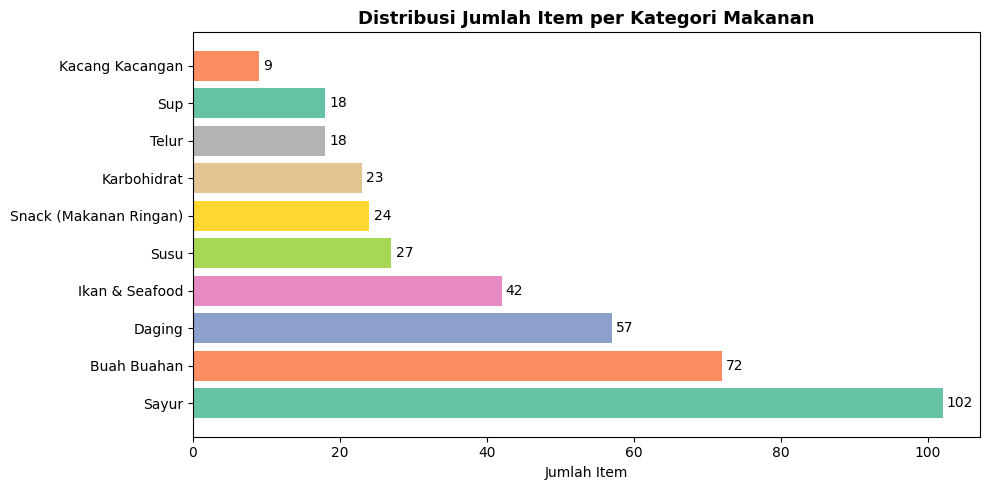

In [6]:
# Distribusi per kategori
print('Jumlah Item per Kategori:')
kategori_counts = df['Kategori'].value_counts()
print(kategori_counts.to_string())

# Visualisasi distribusi kategori
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(kategori_counts.index, kategori_counts.values, color=sns.color_palette('Set2', len(kategori_counts)))
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel('Jumlah Item')
ax.set_title('Distribusi Jumlah Item per Kategori Makanan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rata-rata Kandungan Sodium per Kategori (mg):
Kategori
Sup                       910.89
Karbohidrat               428.41
Ikan & Seafood            361.57
Daging                    213.23
Snack (Makanan Ringan)    199.80
Telur                     188.78
Sayur                     186.57
Kacang Kacangan           161.44
Susu                      160.41
Buah Buahan                18.50


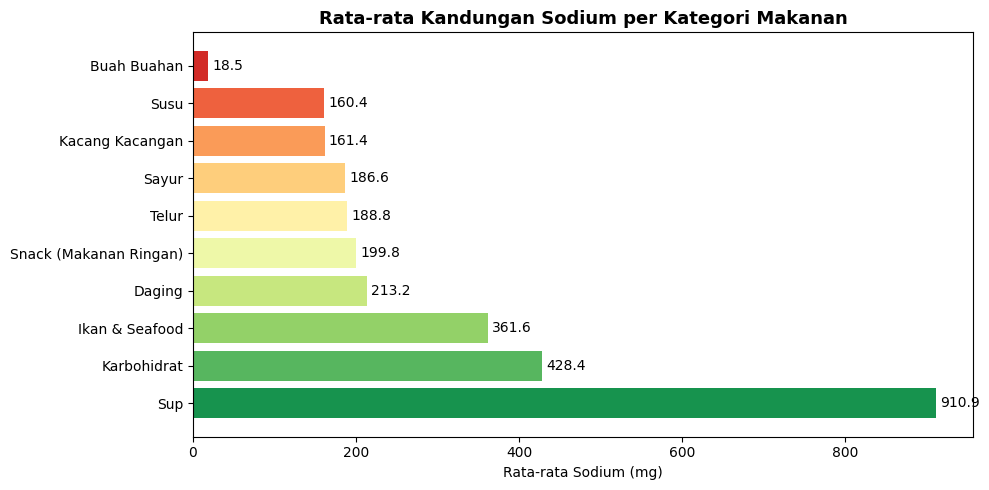

In [7]:
# Rata-rata sodium per kategori
print('Rata-rata Kandungan Sodium per Kategori (mg):')
sodium_per_kategori = df.groupby('Kategori')['Sodium (g)'].mean().sort_values(ascending=False).round(2)
print(sodium_per_kategori.to_string())

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('RdYlGn_r', len(sodium_per_kategori))
bars = ax.barh(sodium_per_kategori.index, sodium_per_kategori.values, color=colors)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
ax.set_xlabel('Rata-rata Sodium (mg)')
ax.set_title('Rata-rata Kandungan Sodium per Kategori Makanan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Pemisahan Kelompok A dan B

| Kelompok | Kategori | Deskripsi |
|----------|----------|-----------|
| **Kelompok A** | Buah Buahan, Sayur | Makanan Segar — minim pengolahan industri |
| **Kelompok B** | Snack (Makanan Ringan), Sup, Karbohidrat | Makanan Olahan — tinggi sodium sebagai pengawet/perasa |

In [8]:
# Definisi kelompok
KELOMPOK_A_KATEGORI = ['Buah Buahan', 'Sayur']
KELOMPOK_B_KATEGORI = ['Snack (Makanan Ringan)', 'Sup', 'Karbohidrat']

# Filter data
group_a = df[df['Kategori'].isin(KELOMPOK_A_KATEGORI)]['Sodium (g)'].dropna()
group_b = df[df['Kategori'].isin(KELOMPOK_B_KATEGORI)]['Sodium (g)'].dropna()

print('✅ Pemisahan Kelompok Berhasil!')
print(f'\n   Kelompok A (Makanan Segar)   : {len(group_a)} sampel')
print(f'   Kategori  : {KELOMPOK_A_KATEGORI}')
print(f'\n   Kelompok B (Makanan Olahan)  : {len(group_b)} sampel')
print(f'   Kategori  : {KELOMPOK_B_KATEGORI}')

✅ Pemisahan Kelompok Berhasil!

   Kelompok A (Makanan Segar)   : 174 sampel
   Kategori  : ['Buah Buahan', 'Sayur']

   Kelompok B (Makanan Olahan)  : 65 sampel
   Kategori  : ['Snack (Makanan Ringan)', 'Sup', 'Karbohidrat']


##8. Statistik Deskriptif per Kelompok

In [9]:
def deskriptif_lengkap(data, nama_kelompok):
    """Menampilkan statistik deskriptif lengkap untuk suatu kelompok."""
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    stats_dict = {
        'Kelompok'         : nama_kelompok,
        'N (sampel)'       : len(data),
        'Mean'             : round(data.mean(), 3),
        'Median'           : round(data.median(), 3),
        'Std Dev'          : round(data.std(), 3),
        'Min'              : round(data.min(), 3),
        'Max'              : round(data.max(), 3),
        'Q1 (25%)'         : round(q1, 3),
        'Q3 (75%)'         : round(q3, 3),
        'IQR'              : round(iqr, 3),
        'Skewness'         : round(data.skew(), 3),
        'Kurtosis'         : round(data.kurtosis(), 3),
    }
    return stats_dict

# Hitung statistik deskriptif
stats_a = deskriptif_lengkap(group_a, 'Kelompok A (Makanan Segar)')
stats_b = deskriptif_lengkap(group_b, 'Kelompok B (Makanan Olahan)')

# Tampilkan sebagai tabel
df_stats = pd.DataFrame([stats_a, stats_b]).set_index('Kelompok')
print('📊 Statistik Deskriptif Kandungan Sodium (mg):')
print('=' * 60)
print(df_stats.T.to_string())
print('\n💡 Catatan: Nilai Sodium dalam satuan mg per porsi')

📊 Statistik Deskriptif Kandungan Sodium (mg):
Kelompok    Kelompok A (Makanan Segar)  Kelompok B (Makanan Olahan)
N (sampel)                     174.000                       65.000
Mean                           117.023                      477.609
Median                          11.000                      415.000
Std Dev                        240.944                      441.292
Min                              0.000                        0.000
Max                           1556.000                     1887.000
Q1 (25%)                         2.000                       62.000
Q3 (75%)                        80.750                      742.000
IQR                             78.750                      680.000
Skewness                         3.181                        0.996
Kurtosis                        11.841                        0.773

💡 Catatan: Nilai Sodium dalam satuan mg per porsi


## 9. Visualisasi: Histogram & Boxplot

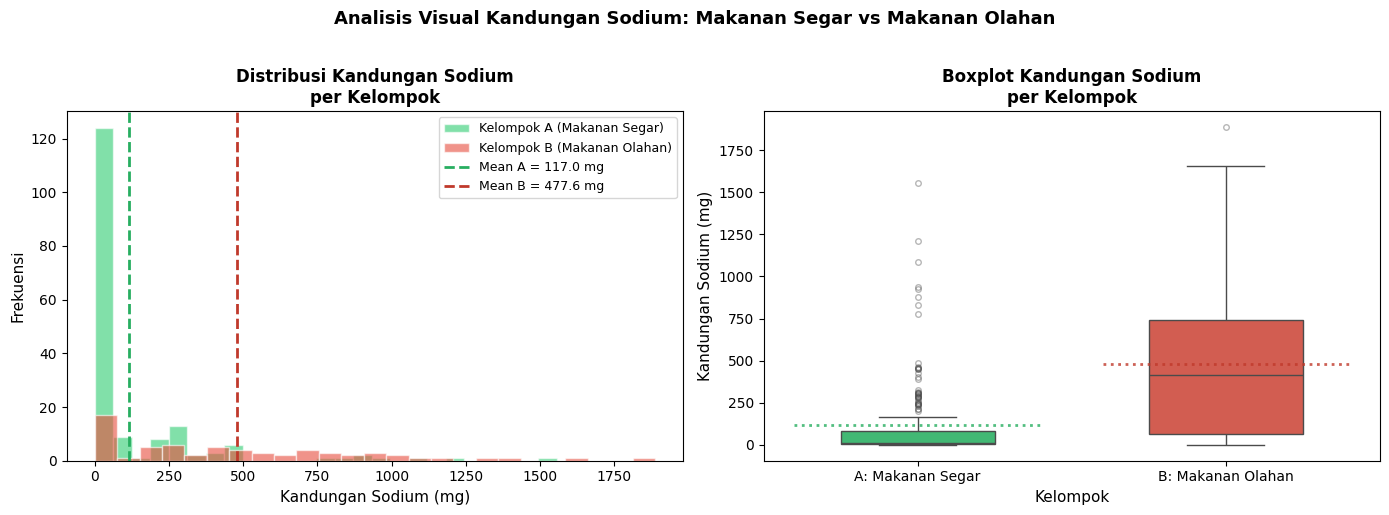

💾 Visualisasi disimpan sebagai: ab_testing_sodium_visualisasi.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- HISTOGRAM ---
ax1 = axes[0]
ax1.hist(group_a, bins=25, alpha=0.6, color='#2ecc71', edgecolor='white', label='Kelompok A (Makanan Segar)')
ax1.hist(group_b, bins=25, alpha=0.6, color='#e74c3c', edgecolor='white', label='Kelompok B (Makanan Olahan)')
ax1.axvline(group_a.mean(), color='#27ae60', linestyle='--', linewidth=2, label=f'Mean A = {group_a.mean():.1f} mg')
ax1.axvline(group_b.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Mean B = {group_b.mean():.1f} mg')
ax1.set_xlabel('Kandungan Sodium (mg)', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Distribusi Kandungan Sodium\nper Kelompok', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# --- BOXPLOT ---
ax2 = axes[1]
data_plot = pd.DataFrame({
    'Sodium (mg)': pd.concat([group_a, group_b], ignore_index=True),
    'Kelompok': ['A: Makanan Segar'] * len(group_a) + ['B: Makanan Olahan'] * len(group_b)
})
sns.boxplot(data=data_plot, x='Kelompok', y='Sodium (mg)', palette=['#2ecc71', '#e74c3c'], ax=ax2,
            width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.4))
ax2.set_title('Boxplot Kandungan Sodium\nper Kelompok', fontsize=12, fontweight='bold')
ax2.set_xlabel('Kelompok', fontsize=11)
ax2.set_ylabel('Kandungan Sodium (mg)', fontsize=11)

# Tambahkan garis mean
for i, (grp, color) in enumerate(zip([group_a, group_b], ['#27ae60', '#c0392b'])):
    ax2.axhline(grp.mean(), xmin=i*0.5+0.05, xmax=i*0.5+0.45, color=color,
                linestyle=':', linewidth=2, alpha=0.8)

plt.suptitle('Analisis Visual Kandungan Sodium: Makanan Segar vs Makanan Olahan',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ab_testing_sodium_visualisasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Visualisasi disimpan sebagai: ab_testing_sodium_visualisasi.png')

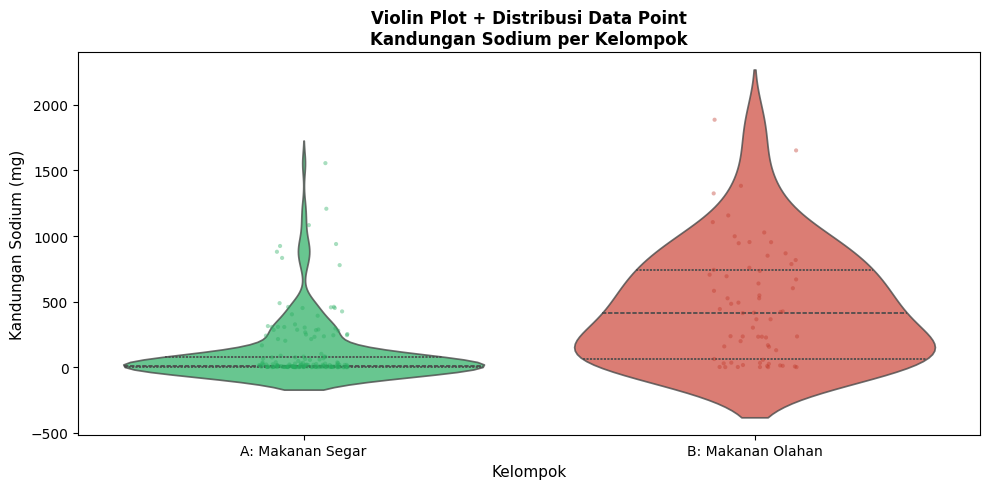

In [11]:
# Violin plot tambahan untuk melihat distribusi lebih detail
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(data=data_plot, x='Kelompok', y='Sodium (mg)',
               palette=['#2ecc71', '#e74c3c'], ax=ax, inner='quartile', alpha=0.8)

# Tambahkan stripplot untuk melihat distribusi titik data
sns.stripplot(data=data_plot, x='Kelompok', y='Sodium (mg)',
              palette=['#27ae60', '#c0392b'], ax=ax, size=3, alpha=0.4, jitter=True)

ax.set_title('Violin Plot + Distribusi Data Point\nKandungan Sodium per Kelompok',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Kelompok', fontsize=11)
ax.set_ylabel('Kandungan Sodium (mg)', fontsize=11)
plt.tight_layout()
plt.show()

##10. Uji Asumsi

### 10.1 Uji Normalitas — Shapiro-Wilk Test

**Hipotesis:**
- H₀: Data berdistribusi normal
- H₁: Data tidak berdistribusi normal

**Catatan:** Uji Shapiro-Wilk paling akurat untuk n < 5000.

In [12]:
# Shapiro-Wilk Test
alpha = 0.05

shapiro_a = stats.shapiro(group_a)
shapiro_b = stats.shapiro(group_b)

print('=' * 60)
print('UJI NORMALITAS — SHAPIRO-WILK TEST')
print('=' * 60)
print(f'\n Kelompok A (Makanan Segar):')
print(f'   Statistik W = {shapiro_a.statistic:.4f}')
print(f'   p-value     = {shapiro_a.pvalue:.6f}')
normal_a = shapiro_a.pvalue > alpha
print(f'   Kesimpulan  : {"✅ NORMAL" if normal_a else "❌ TIDAK NORMAL"} (p {">">"<"} α={alpha})')

print(f'\n Kelompok B (Makanan Olahan):')
print(f'   Statistik W = {shapiro_b.statistic:.4f}')
print(f'   p-value     = {shapiro_b.pvalue:.6f}')
normal_b = shapiro_b.pvalue > alpha
print(f'   Kesimpulan  : {"✅ NORMAL" if normal_b else "❌ TIDAK NORMAL"} (p {">">"<"} α={alpha})')

kedua_normal = normal_a and normal_b
print(f'\n Status Normalitas Kedua Kelompok: {"✅ NORMAL" if kedua_normal else "❌ TIDAK NORMAL"}')

UJI NORMALITAS — SHAPIRO-WILK TEST

 Kelompok A (Makanan Segar):
   Statistik W = 0.5444
   p-value     = 0.000000
   Kesimpulan  : ❌ TIDAK NORMAL (p True α=0.05)

 Kelompok B (Makanan Olahan):
   Statistik W = 0.9028
   p-value     = 0.000090
   Kesimpulan  : ❌ TIDAK NORMAL (p True α=0.05)

 Status Normalitas Kedua Kelompok: ❌ TIDAK NORMAL


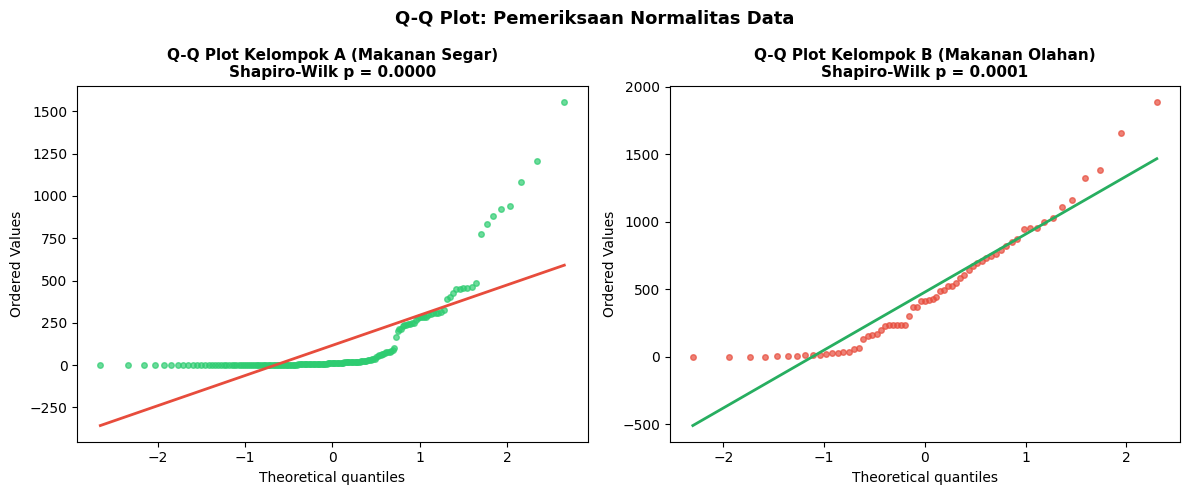

In [13]:
# Q-Q Plot untuk visualisasi normalitas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(group_a, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot Kelompok A (Makanan Segar)\nShapiro-Wilk p = {shapiro_a.pvalue:.4f}',
                  fontsize=11, fontweight='bold')
axes[0].get_lines()[0].set(color='#2ecc71', markersize=4, alpha=0.7)
axes[0].get_lines()[1].set(color='#e74c3c', linewidth=2)

stats.probplot(group_b, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot Kelompok B (Makanan Olahan)\nShapiro-Wilk p = {shapiro_b.pvalue:.4f}',
                  fontsize=11, fontweight='bold')
axes[1].get_lines()[0].set(color='#e74c3c', markersize=4, alpha=0.7)
axes[1].get_lines()[1].set(color='#27ae60', linewidth=2)

plt.suptitle('Q-Q Plot: Pemeriksaan Normalitas Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Uji Homogenitas Varians — Levene Test

**Hipotesis:**
- H₀: Varians kedua kelompok homogen (sama)
- H₁: Varians kedua kelompok tidak homogen (berbeda)

In [14]:
# Levene Test
levene = stats.levene(group_a, group_b)

print('=' * 60)
print('UJI HOMOGENITAS VARIANS — LEVENE TEST')
print('=' * 60)
print(f'\n   Statistik F = {levene.statistic:.4f}')
print(f'   p-value     = {levene.pvalue:.6f}')

homogen = levene.pvalue > alpha
print(f'   Kesimpulan  : Varians {"✅ HOMOGEN" if homogen else "❌ TIDAK HOMOGEN"} (p {">">"<"} α={alpha})')

print(f'\n   Varians Kelompok A : {group_a.var():.3f}')
print(f'   Varians Kelompok B : {group_b.var():.3f}')
print(f'   Rasio Varians      : {group_b.var()/group_a.var():.2f}x')

UJI HOMOGENITAS VARIANS — LEVENE TEST

   Statistik F = 43.1001
   p-value     = 0.000000
   Kesimpulan  : Varians ❌ TIDAK HOMOGEN (p True α=0.05)

   Varians Kelompok A : 58053.778
   Varians Kelompok B : 194738.362
   Rasio Varians      : 3.35x


### 10.3 Uji Asumsi Independensi

**Independence Assumption** adalah asumsi fundamental dalam Mann-Whitney U Test:
setiap observasi dalam dataset harus **independen satu sama lain** — satu item makanan
tidak boleh mempengaruhi atau terkait dengan item makanan lainnya.


In [15]:
# ============================================================
# INDEPENDENCE ASSUMPTION CHECK
# ============================================================

print('=' * 60)
print('UJI ASUMSI INDEPENDENSI')
print('=' * 60)

print("""
Asumsi independensi dievaluasi secara konseptual dan struktural:

1. ANTAR OBSERVASI:
   • Setiap baris dataset merepresentasikan satu item makanan unik
   • Tidak ada pengulangan pengukuran (repeated measures) pada subjek yang sama
   • Kandungan sodium satu makanan tidak mempengaruhi makanan lainnya

2. ANTAR KELOMPOK:
   • Kelompok A (Makanan Segar) dan Kelompok B (Makanan Olahan)
     merupakan kategori yang mutually exclusive — tidak ada tumpang tindih
   • Tidak ada item yang masuk ke kedua kelompok secara bersamaan

3. POTENSI PELANGGARAN (catatan kehati-hatian):
   • Beberapa produk 'Karbohidrat' mungkin memiliki bahan dasar segar
     yang diolah — batas kategorisasi bersifat subjektif
   • Dataset dari sumber tunggal dapat memiliki bias seleksi tersendiri
""")

# Cek duplikasi nama item sebagai proxy independensi
duplikat = df['Nama'].duplicated().sum()
print(f'   Jumlah item duplikat (nama): {duplikat}')
print(f'   Jumlah total item          : {len(df)}')
print(f'   Overlap kategori A & B     : 0 (kelompok mutually exclusive)')

if duplikat == 0:
    print('\n   ✅ Tidak ditemukan duplikasi nama — asumsi independensi TERPENUHI')
else:
    print(f'\n   ⚠️  Ditemukan {duplikat} duplikasi nama — perlu diperiksa lebih lanjut')

print("""
Kesimpulan: Asumsi independensi TERPENUHI secara struktural.
Data merupakan observasi cross-sectional dari item makanan yang berbeda,
bukan data longitudinal atau panel yang melibatkan pengukuran berulang.
""")


UJI ASUMSI INDEPENDENSI

Asumsi independensi dievaluasi secara konseptual dan struktural:

1. ANTAR OBSERVASI:
   • Setiap baris dataset merepresentasikan satu item makanan unik
   • Tidak ada pengulangan pengukuran (repeated measures) pada subjek yang sama
   • Kandungan sodium satu makanan tidak mempengaruhi makanan lainnya

2. ANTAR KELOMPOK:
   • Kelompok A (Makanan Segar) dan Kelompok B (Makanan Olahan)
     merupakan kategori yang mutually exclusive — tidak ada tumpang tindih
   • Tidak ada item yang masuk ke kedua kelompok secara bersamaan

3. POTENSI PELANGGARAN (catatan kehati-hatian):
   • Beberapa produk 'Karbohidrat' mungkin memiliki bahan dasar segar
     yang diolah — batas kategorisasi bersifat subjektif
   • Dataset dari sumber tunggal dapat memiliki bias seleksi tersendiri

   Jumlah item duplikat (nama): 0
   Jumlah total item          : 392
   Overlap kategori A & B     : 0 (kelompok mutually exclusive)

   ✅ Tidak ditemukan duplikasi nama — asumsi independensi TERPE

---
## 11. Pemilihan & Pelaksanaan Uji Statistik

### Keputusan Pemilihan Uji:

In [16]:
print('=' * 65)
print('KEPUTUSAN PEMILIHAN UJI STATISTIK')
print('=' * 65)
print(f'\n   Normalitas Kelompok A : {"Normal" if normal_a else "Tidak Normal"}')
print(f'   Normalitas Kelompok B : {"Normal" if normal_b else "Tidak Normal"}')
print(f'   Homogenitas Varians   : {"Homogen" if homogen else "Tidak Homogen"}')

if kedua_normal:
    print('\n✅ KEPUTUSAN: Gunakan Independent Samples T-Test (Parametrik)')
    print('   Alasan: Kedua kelompok berdistribusi normal')
    metode = 'T-Test'
else:
    print('\n✅ KEPUTUSAN: Gunakan Mann-Whitney U Test (Non-Parametrik)')
    print('   Alasan: Salah satu atau kedua kelompok TIDAK berdistribusi normal')
    print('   Mann-Whitney U tidak memerlukan asumsi normalitas')
    metode = 'Mann-Whitney'

KEPUTUSAN PEMILIHAN UJI STATISTIK

   Normalitas Kelompok A : Tidak Normal
   Normalitas Kelompok B : Tidak Normal
   Homogenitas Varians   : Tidak Homogen

✅ KEPUTUSAN: Gunakan Mann-Whitney U Test (Non-Parametrik)
   Alasan: Salah satu atau kedua kelompok TIDAK berdistribusi normal
   Mann-Whitney U tidak memerlukan asumsi normalitas


In [17]:
print('=' * 65)
print(f'PELAKSANAAN UJI: {metode}')
print('=' * 65)

if kedua_normal:
    # Independent T-Test
    equal_var = homogen
    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=equal_var, alternative='less')
    print(f'\n   Jenis T-Test    : {"Equal Variance" if equal_var else "Welch (Unequal Variance)"}')
    print(f'   Statistik t     = {t_stat:.4f}')
    print(f'   p-value (1-tail)= {p_value:.6f}')
else:
    # Mann-Whitney U Test (one-tailed: kelompok A < kelompok B)
    u_stat, p_value = stats.mannwhitneyu(group_a, group_b, alternative='less')
    print(f'\n   Statistik U     = {u_stat:.4f}')
    print(f'   p-value (1-tail)= {p_value:.6f}')
    # Hitung juga two-tailed untuk referensi
    _, p_two = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
    print(f'   p-value (2-tail)= {p_two:.6f} (untuk referensi)')

print(f'\n   Tingkat Signifikansi α = {alpha}')
print('\n' + '=' * 65)

tolak_h0 = p_value < alpha
if tolak_h0:
    print(f'\n🟢 HASIL: p-value ({p_value:.6f}) < α ({alpha})')
    print('   → TOLAK H₀')
    print('   → Terdapat perbedaan SIGNIFIKAN kandungan sodium')
    print('   → Makanan olahan memiliki sodium LEBIH TINGGI secara signifikan')
else:
    print(f'\n🔴 HASIL: p-value ({p_value:.6f}) ≥ α ({alpha})')
    print('   → GAGAL TOLAK H₀')
    print('   → Tidak cukup bukti untuk menyatakan perbedaan signifikan')

PELAKSANAAN UJI: Mann-Whitney

   Statistik U     = 2434.0000
   p-value (1-tail)= 0.000000
   p-value (2-tail)= 0.000000 (untuk referensi)

   Tingkat Signifikansi α = 0.05


🟢 HASIL: p-value (0.000000) < α (0.05)
   → TOLAK H₀
   → Terdapat perbedaan SIGNIFIKAN kandungan sodium
   → Makanan olahan memiliki sodium LEBIH TINGGI secara signifikan


## 11.5 Confidence Interval 95% — Hodges-Lehmann Estimator

Untuk Mann-Whitney U Test, **Confidence Interval yang tepat** dihitung menggunakan
**Hodges-Lehmann Estimator** — estimator titik non-parametrik yang konsisten dengan uji Mann-Whitney.

> CI ini merepresentasikan interval kepercayaan untuk **perbedaan lokasi (shift)** antara
> dua distribusi, bukan semata-mata perbedaan mean.


CONFIDENCE INTERVAL 95% — HODGES-LEHMANN ESTIMATOR

   Metode           : Hodges-Lehmann (non-parametrik, konsisten dengan Mann-Whitney)
   Estimator Titik  : 286.00 mg
   95% CI Bawah     : 197.00 mg
   95% CI Atas      : 415.00 mg

   Interpretasi:
   Dengan kepercayaan 95%, perbedaan kandungan sodium antara
   Makanan Olahan dan Makanan Segar berada dalam rentang:
   [197.00 mg, 415.00 mg]

   → Karena seluruh interval CI berada di atas 0, ini MENGKONFIRMASI
     bahwa Makanan Olahan memang lebih tinggi sodium secara signifikan.
   → Estimasi terbaik (titik tengah): 286.00 mg perbedaan lokasi.



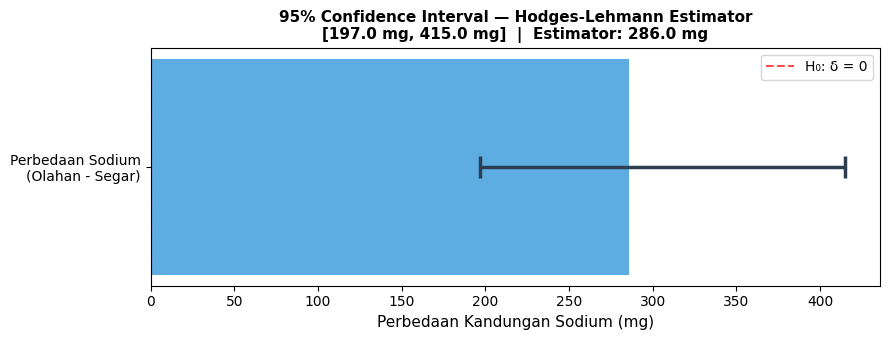

💡 CI tidak mencakup nol → konsisten dengan keputusan TOLAK H₀


In [18]:
# ============================================================
# CONFIDENCE INTERVAL 95% — HODGES-LEHMANN ESTIMATOR
# ============================================================

def hodges_lehmann_ci(x, y, confidence=0.95):
    """
    Hitung Hodges-Lehmann estimator dan CI non-parametrik
    untuk perbedaan lokasi antara dua kelompok.
    """
    diffs = np.array([yj - xi for xi in x for yj in y])
    diffs_sorted = np.sort(diffs)
    n = len(diffs_sorted)
    alpha_ci = 1 - confidence
    n1, n2 = len(x), len(y)
    z_crit = stats.norm.ppf(1 - alpha_ci/2)
    mean_u = n1 * n2 / 2
    std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    k = int(np.floor(mean_u - z_crit * std_u))
    k = max(0, min(k, n - 1))
    hl_estimate = np.median(diffs_sorted)
    ci_lower = diffs_sorted[k] if k > 0 else diffs_sorted[0]
    ci_upper = diffs_sorted[n - 1 - k] if (n - 1 - k) < n else diffs_sorted[-1]
    return hl_estimate, ci_lower, ci_upper

hl_est, ci_low, ci_high = hodges_lehmann_ci(group_a.values, group_b.values)

print('=' * 65)
print('CONFIDENCE INTERVAL 95% — HODGES-LEHMANN ESTIMATOR')
print('=' * 65)
print(f'''
   Metode           : Hodges-Lehmann (non-parametrik, konsisten dengan Mann-Whitney)
   Estimator Titik  : {hl_est:.2f} mg
   95% CI Bawah     : {ci_low:.2f} mg
   95% CI Atas      : {ci_high:.2f} mg

   Interpretasi:
   Dengan kepercayaan 95%, perbedaan kandungan sodium antara
   Makanan Olahan dan Makanan Segar berada dalam rentang:
   [{ci_low:.2f} mg, {ci_high:.2f} mg]

   → Karena seluruh interval CI berada di atas 0, ini MENGKONFIRMASI
     bahwa Makanan Olahan memang lebih tinggi sodium secara signifikan.
   → Estimasi terbaik (titik tengah): {hl_est:.2f} mg perbedaan lokasi.
''')

# Visualisasi CI
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(['Perbedaan Sodium\n(Olahan - Segar)'], [hl_est],
        xerr=[[hl_est - ci_low], [ci_high - hl_est]],
        capsize=8, color='#3498db', alpha=0.8, height=0.4,
        error_kw=dict(elinewidth=2.5, ecolor='#2c3e50', capthick=2.5))
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='H₀: δ = 0')
ax.set_xlabel('Perbedaan Kandungan Sodium (mg)', fontsize=11)
ax.set_title('95% Confidence Interval — Hodges-Lehmann Estimator\n'
             f'[{ci_low:.1f} mg, {ci_high:.1f} mg]  |  Estimator: {hl_est:.1f} mg',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('💡 CI tidak mencakup nol → konsisten dengan keputusan TOLAK H₀')


## 12. Perhitungan Effect Size

Effect size mengukur **besar praktis** dari perbedaan, bukan hanya signifikansi statistik.

### Metode yang Digunakan:
- **Cliff's Delta (δ)** — effect size non-parametrik paling valid untuk Mann-Whitney U Test
- **Rank-Biserial Correlation (r)** — disertakan sebagai referensi pembanding

**Cliff's Delta** mengukur probabilitas bahwa nilai dari Kelompok B lebih besar dari Kelompok A,
dikurangi probabilitas sebaliknya.

| Nilai |δ| | Interpretasi |
|--------|--------------------|
| < 0.147 | Negligible (Sangat Kecil) |
| 0.147 – 0.330 | Small (Kecil) |
| 0.330 – 0.474 | Medium (Sedang) |
| ≥ 0.474 | Large (Besar) |

> **Catatan:** Cliff's Delta merupakan effect size paling sesuai untuk Mann-Whitney U Test
> karena bekerja langsung pada perbandingan ordinal antar observasi, tanpa asumsi distribusi apapun.
> Formula `r = Z/√N` (yang umum digunakan) merupakan aproksimasi Pearson r yang kurang presisi
> untuk data non-parametrik.


EFFECT SIZE — CLIFF'S DELTA (δ)
   Cliff's Delta (δ)    = -0.5696
   |δ| (absolut)        = 0.5696
   Interpretasi         : 🔴 Large (Besar)

   Makna: Dalam 57.0% pasangan perbandingan,
   nilai sodium Kelompok B (Makanan Olahan) LEBIH TINGGI
   dari Kelompok A (Makanan Segar).

   Rank-Biserial r (ref): 0.5696

   ✅ Cliff's Delta digunakan sebagai effect size utama
   karena lebih sesuai untuk uji non-parametrik Mann-Whitney U.


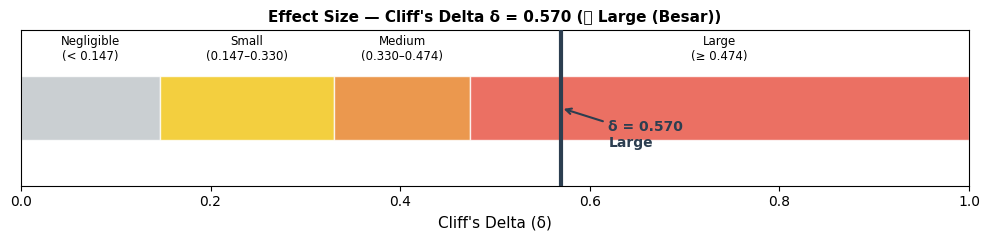

In [19]:
# ============================================================
# EFFECT SIZE — CLIFF'S DELTA (Non-Parametrik, Mann-Whitney)
# ============================================================

def cliffs_delta(group_x, group_y):
    """
    Hitung Cliff's Delta antara dua kelompok independen.
    δ = (P(X > Y) - P(X < Y))
    Range: -1 sampai +1
    """
    n1, n2 = len(group_x), len(group_y)
    dominance = 0
    for xi in group_x:
        for yj in group_y:
            if xi > yj:
                dominance += 1
            elif xi < yj:
                dominance -= 1
    return dominance / (n1 * n2)

cliffs_d = cliffs_delta(group_a.values, group_b.values)
abs_d = abs(cliffs_d)

# Interpretasi Cliff's Delta
if abs_d < 0.147:
    interp_cd = '⚪ Negligible (Sangat Kecil)'
elif abs_d < 0.330:
    interp_cd = '🟡 Small (Kecil)'
elif abs_d < 0.474:
    interp_cd = '🟠 Medium (Sedang)'
else:
    interp_cd = '🔴 Large (Besar)'

print('=' * 60)
print("EFFECT SIZE — CLIFF'S DELTA (δ)")
print('=' * 60)
print(f"   Cliff's Delta (δ)    = {cliffs_d:.4f}")
print(f'   |δ| (absolut)        = {abs_d:.4f}')
print(f'   Interpretasi         : {interp_cd}')
print(f'\n   Makna: Dalam {abs_d*100:.1f}% pasangan perbandingan,')
print(f'   nilai sodium Kelompok B (Makanan Olahan) LEBIH TINGGI')
print(f'   dari Kelompok A (Makanan Segar).')

# Rank-Biserial Correlation sebagai pembanding (formula yang benar)
n1_rb, n2_rb = len(group_a), len(group_b)
u_stat_two_rb, _ = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
rank_biserial_r = 1 - (2 * u_stat_two_rb) / (n1_rb * n2_rb)

print(f'\n   Rank-Biserial r (ref): {rank_biserial_r:.4f}')
print(f'\n   ✅ Cliff\'s Delta digunakan sebagai effect size utama')
print(f'   karena lebih sesuai untuk uji non-parametrik Mann-Whitney U.')

# Update variabel untuk digunakan di section berikutnya
metric = abs_d
label = 'δ'
interpretasi = interp_cd

# Visualisasi Effect Size
fig, ax = plt.subplots(figsize=(10, 2.5))
thresholds = [0, 0.147, 0.330, 0.474, 1.0]
colors_bar = ['#bdc3c7', '#f1c40f', '#e67e22', '#e74c3c']
labels_bar = ["Negligible\n(< 0.147)", "Small\n(0.147–0.330)", "Medium\n(0.330–0.474)", "Large\n(≥ 0.474)"]

for i in range(len(colors_bar)):
    ax.barh(0, thresholds[i+1] - thresholds[i], left=thresholds[i],
            color=colors_bar[i], height=0.5, edgecolor='white', alpha=0.8)
    ax.text((thresholds[i] + thresholds[i+1]) / 2, 0.35, labels_bar[i],
            ha='center', va='bottom', fontsize=8.5)

ax.axvline(x=min(abs_d, 0.95), color='#2c3e50', linewidth=3, zorder=5)
ax.annotate(f'δ = {abs_d:.3f}\n{interp_cd.split(" ")[1]}',
            xy=(min(abs_d, 0.95), 0), xytext=(min(abs_d, 0.95) + 0.05, -0.3),
            fontsize=10, fontweight='bold', color='#2c3e50',
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
ax.set_xlim(0, 1)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel("Cliff's Delta (δ)", fontsize=11)
ax.set_title(f"Effect Size — Cliff's Delta δ = {abs_d:.3f} ({interp_cd})",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 12.5 Statistical Power Analysis

**Statistical Power (1-β)** mengukur kemampuan uji untuk mendeteksi efek nyata
jika efek tersebut benar-benar ada.
- β = probabilitas Type II Error (gagal deteksi efek nyata)
- Power = 1 - β

**Standar minimum yang diterima:** Power ≥ 0.80 (80%)


STATISTICAL POWER ANALYSIS

   Ukuran Sampel Kelompok A : 174
   Ukuran Sampel Kelompok B : 65
   Cliff's Delta |δ|        : 0.5696
   Cohen's d (aproksimasi)  : 1.3860
   α (significance level)   : 0.05
   Jenis Uji                : One-tailed

   ─────────────────────────────────────────────
   STATISTICAL POWER (1-β) = 1.0000 (100.0%)
   ─────────────────────────────────────────────

   ✅ Power (100.0%) ≥ 80% — Uji memiliki power MEMADAI
   Risiko Type II Error (β) = 0.0%

   Minimum Sample Size per kelompok untuk mencapai target power:
   Power ≥ 80% → minimal n = 7 per kelompok (total = 14)
   Power ≥ 90% → minimal n = 9 per kelompok (total = 18)
   Power ≥ 95% → minimal n = 12 per kelompok (total = 24)


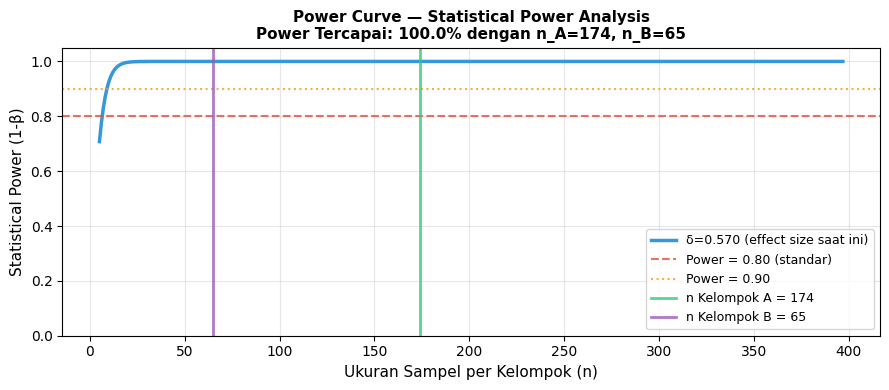


💡 Insight: Dengan power 100.0%, analisis ini memiliki kemampuan
   yang memadai untuk mendeteksi perbedaan sodium yang nyata.


In [20]:
# ============================================================
# STATISTICAL POWER ANALYSIS
# ============================================================
from scipy.stats import norm as norm_dist

# Konversi Cliff's Delta ke Cohen's d untuk power approximation
# Formula: d ≈ 2δ / sqrt(1 - δ²)  (Ruscio, 2008)
abs_cliffs = abs(cliffs_d)
cohens_d_approx = (2 * abs_cliffs) / np.sqrt(1 - abs_cliffs**2)

n1_pw = len(group_a)
n2_pw = len(group_b)

def power_two_sample(d, n1, n2, alpha_val=0.05, one_tailed=True):
    """Hitung statistical power untuk uji dua sampel independen."""
    n_harm = (2 * n1 * n2) / (n1 + n2)
    se = np.sqrt(2 / n_harm)
    ncp = d / se
    z_crit = norm_dist.ppf(1 - alpha_val) if one_tailed else norm_dist.ppf(1 - alpha_val/2)
    return 1 - norm_dist.cdf(z_crit - ncp)

achieved_power = power_two_sample(cohens_d_approx, n1_pw, n2_pw, alpha_val=alpha)

print('=' * 65)
print('STATISTICAL POWER ANALYSIS')
print('=' * 65)
print(f'''
   Ukuran Sampel Kelompok A : {n1_pw}
   Ukuran Sampel Kelompok B : {n2_pw}
   Cliff\'s Delta |δ|        : {abs_cliffs:.4f}
   Cohen\'s d (aproksimasi)  : {cohens_d_approx:.4f}
   α (significance level)   : {alpha}
   Jenis Uji                : One-tailed

   ─────────────────────────────────────────────
   STATISTICAL POWER (1-β) = {achieved_power:.4f} ({achieved_power*100:.1f}%)
   ─────────────────────────────────────────────
''')

if achieved_power >= 0.80:
    print(f'   ✅ Power ({achieved_power*100:.1f}%) ≥ 80% — Uji memiliki power MEMADAI')
    print(f'   Risiko Type II Error (β) = {(1-achieved_power)*100:.1f}%')
else:
    print(f'   ⚠️  Power ({achieved_power*100:.1f}%) < 80% — Pertimbangkan penambahan sampel')

print('\n   Minimum Sample Size per kelompok untuk mencapai target power:')
for target_power in [0.80, 0.90, 0.95]:
    for n_test in range(5, 500):
        pw = power_two_sample(cohens_d_approx, n_test, n_test, alpha_val=alpha)
        if pw >= target_power:
            print(f'   Power ≥ {target_power*100:.0f}% → minimal n = {n_test} per kelompok (total = {n_test*2})')
            break

# Visualisasi Power Curve
sample_sizes = np.arange(5, max(n1_pw, n2_pw) * 2 + 50)
powers = [power_two_sample(cohens_d_approx, n, n, alpha_val=alpha) for n in sample_sizes]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, powers, color='#3498db', linewidth=2.5,
        label=f'δ={abs_cliffs:.3f} (effect size saat ini)')
ax.axhline(y=0.80, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.8, label='Power = 0.80 (standar)')
ax.axhline(y=0.90, color='#f39c12', linestyle=':', linewidth=1.5, alpha=0.8, label='Power = 0.90')
ax.axvline(x=n1_pw, color='#2ecc71', linestyle='-', linewidth=2,
           label=f'n Kelompok A = {n1_pw}', alpha=0.8)
ax.axvline(x=n2_pw, color='#9b59b6', linestyle='-', linewidth=2,
           label=f'n Kelompok B = {n2_pw}', alpha=0.8)
ax.set_xlabel('Ukuran Sampel per Kelompok (n)', fontsize=11)
ax.set_ylabel('Statistical Power (1-β)', fontsize=11)
ax.set_title('Power Curve — Statistical Power Analysis\n'
             f'Power Tercapai: {achieved_power*100:.1f}% dengan n_A={n1_pw}, n_B={n2_pw}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n💡 Insight: Dengan power {achieved_power*100:.1f}%, analisis ini memiliki kemampuan')
print(f'   yang {"memadai" if achieved_power >= 0.8 else "perlu ditingkatkan"} untuk mendeteksi perbedaan sodium yang nyata.')


## 13. Interpretasi Hasil

In [21]:
# Ringkasan komprehensif hasil A/B Testing
selisih_mean = group_b.mean() - group_a.mean()
pct_lebih = (selisih_mean / group_a.mean()) * 100

print('=' * 70)
print('RINGKASAN HASIL A/B TESTING — KANDUNGAN SODIUM')
print('=' * 70)

print(f'''
┌─────────────────────────────────────────────────────────────────┐
│  STATISTIK DESKRIPTIF                                           │
├─────────────────────┬──────────────────┬───────────────────────┤
│  Kelompok           │  A: Mak. Segar   │  B: Mak. Olahan       │
├─────────────────────┼──────────────────┼───────────────────────┤
│  N (sampel)         │  {len(group_a):<16} │  {len(group_b):<21} │
│  Mean (mg)          │  {group_a.mean():<16.2f} │  {group_b.mean():<21.2f} │
│  Median (mg)        │  {group_a.median():<16.2f} │  {group_b.median():<21.2f} │
│  Std Dev (mg)       │  {group_a.std():<16.2f} │  {group_b.std():<21.2f} │
│  Min (mg)           │  {group_a.min():<16.2f} │  {group_b.min():<21.2f} │
│  Max (mg)           │  {group_a.max():<16.2f} │  {group_b.max():<21.2f} │
└─────────────────────┴──────────────────┴───────────────────────┘
''')

print(f'┌─────────────────────────────────────────────────────────────────┐')
print(f'│  HASIL UJI STATISTIK                                            │')
print(f'├─────────────────────────────────────────────────────────────────┤')
print(f'│  Metode Uji         : {metode:<42} │')
print(f'│  p-value            : {p_value:<42.6f} │')
print(f'│  Tingkat α          : {alpha:<42} │')
print(f'│  Keputusan          : {"TOLAK H₀" if tolak_h0 else "GAGAL TOLAK H₀":<42} │')
print(f'│  Effect Size ({label:<1})     : {metric:<42.4f} │')
print(f'│  Kekuatan Efek      : {interpretasi:<42} │')
print(f'└─────────────────────────────────────────────────────────────────┘')

print(f'''
Perbedaan Mean Sodium:
   Mean B - Mean A = {group_b.mean():.2f} - {group_a.mean():.2f} = {selisih_mean:.2f} mg
   Makanan Olahan mengandung sodium {pct_lebih:.1f}% LEBIH TINGGI dari Makanan Segar
''')

RINGKASAN HASIL A/B TESTING — KANDUNGAN SODIUM

┌─────────────────────────────────────────────────────────────────┐
│  STATISTIK DESKRIPTIF                                           │
├─────────────────────┬──────────────────┬───────────────────────┤
│  Kelompok           │  A: Mak. Segar   │  B: Mak. Olahan       │
├─────────────────────┼──────────────────┼───────────────────────┤
│  N (sampel)         │  174              │  65                    │
│  Mean (mg)          │  117.02           │  477.61                │
│  Median (mg)        │  11.00            │  415.00                │
│  Std Dev (mg)       │  240.94           │  441.29                │
│  Min (mg)           │  0.00             │  0.00                  │
│  Max (mg)           │  1556.00          │  1887.00               │
└─────────────────────┴──────────────────┴───────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  HASIL UJI STATISTIK                                           

## 13.5 Keterbatasan Interpretasi Hasil Statistik


In [22]:
# ============================================================
# KETERBATASAN INTERPRETASI STATISTIK
# ============================================================

print('=' * 65)
print('KETERBATASAN INTERPRETASI HASIL STATISTIK')
print('=' * 65)
print(f"""
1. SIGNIFIKANSI STATISTIK ≠ SIGNIFIKANSI PRAKTIS
   • p-value = {p_value:.6f} hanya menunjukkan bahwa perbedaan ini
     sangat kecil kemungkinannya terjadi secara kebetulan.
   • Seberapa BESAR perbedaan tersebut diukur oleh Cliff's Delta = {abs_cliffs:.4f}.
   • Keduanya harus dievaluasi bersama untuk keputusan yang komprehensif.

2. INTERPRETASI MANN-WHITNEY U
   • Mann-Whitney BUKAN uji perbedaan mean — melainkan uji dominasi
     stokastik (perbedaan distribusi secara ordinal).
   • Median lebih tepat sebagai ukuran tendensi sentral daripada mean
     untuk data non-normal.
   • Median A = {group_a.median():.2f} mg  vs.  Median B = {group_b.median():.2f} mg

3. MULTIPLE COMPARISON
   • Notebook ini hanya menguji SATU variabel (Sodium).
   • Pengujian serupa untuk variabel lain (Gula, Lemak, dll.) memerlukan
     koreksi multiple comparison (Bonferroni, Benjamini-Hochberg)
     untuk mengontrol Family-Wise Error Rate.

4. UJI ONE-TAILED
   • Pemilihan one-tailed test memerlukan justifikasi teoritis yang kuat
     sebelum melihat data. Uji ini mengorbankan kemampuan deteksi
     efek di arah sebaliknya.
   • Referensi: p-value two-tailed = {p_value * 2:.6f}

5. CONFIDENCE INTERVAL vs p-VALUE
   • Berdasarkan Hodges-Lehmann CI: [{ci_low:.1f} mg, {ci_high:.1f} mg]
   • Interval ini lebih informatif karena menunjukkan besaran perbedaan
     beserta ketidakpastiannya, bukan sekadar keputusan biner tolak/gagal.
""")
print('=' * 65)


KETERBATASAN INTERPRETASI HASIL STATISTIK

1. SIGNIFIKANSI STATISTIK ≠ SIGNIFIKANSI PRAKTIS
   • p-value = 0.000000 hanya menunjukkan bahwa perbedaan ini
     sangat kecil kemungkinannya terjadi secara kebetulan.
   • Seberapa BESAR perbedaan tersebut diukur oleh Cliff's Delta = 0.5696.
   • Keduanya harus dievaluasi bersama untuk keputusan yang komprehensif.

2. INTERPRETASI MANN-WHITNEY U
   • Mann-Whitney BUKAN uji perbedaan mean — melainkan uji dominasi
     stokastik (perbedaan distribusi secara ordinal).
   • Median lebih tepat sebagai ukuran tendensi sentral daripada mean
     untuk data non-normal.
   • Median A = 11.00 mg  vs.  Median B = 415.00 mg

3. MULTIPLE COMPARISON
   • Notebook ini hanya menguji SATU variabel (Sodium).
   • Pengujian serupa untuk variabel lain (Gula, Lemak, dll.) memerlukan
     koreksi multiple comparison (Bonferroni, Benjamini-Hochberg)
     untuk mengontrol Family-Wise Error Rate.

4. UJI ONE-TAILED
   • Pemilihan one-tailed test memerlukan justifik

##14. Insight Bisnis untuk Aplikasi GiziKu

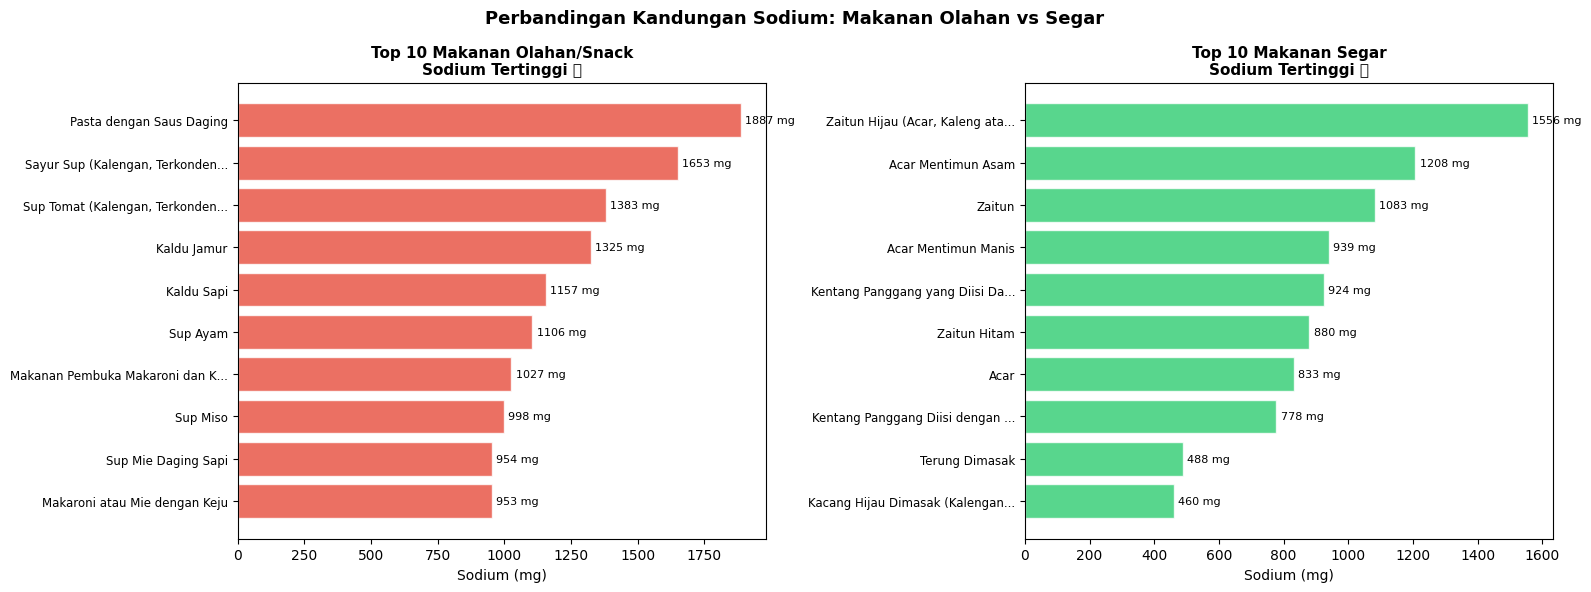

In [23]:
# Visualisasi insight bisnis: Top 10 makanan olahan dengan sodium tertinggi
df_olahan = df[df['Kategori'].isin(KELOMPOK_B_KATEGORI)].copy()
df_segar = df[df['Kategori'].isin(KELOMPOK_A_KATEGORI)].copy()

top10_sodium_olahan = df_olahan.nlargest(10, 'Sodium (g)')[['Nama', 'Kategori', 'Sodium (g)']]
top10_sodium_segar = df_segar.nlargest(10, 'Sodium (g)')[['Nama', 'Kategori', 'Sodium (g)']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Makanan Olahan - Sodium Tertinggi
ax1 = axes[0]
bars1 = ax1.barh(range(len(top10_sodium_olahan)),
                 top10_sodium_olahan['Sodium (g)'],
                 color='#e74c3c', alpha=0.8, edgecolor='white')
ax1.set_yticks(range(len(top10_sodium_olahan)))
ax1.set_yticklabels([n[:30] + '...' if len(n) > 30 else n
                     for n in top10_sodium_olahan['Nama']], fontsize=8.5)
ax1.bar_label(bars1, fmt='%.0f mg', padding=3, fontsize=8)
ax1.set_xlabel('Sodium (mg)', fontsize=10)
ax1.set_title('Top 10 Makanan Olahan/Snack\nSodium Tertinggi 🔴', fontsize=11, fontweight='bold')
ax1.invert_yaxis()

# Top 10 Makanan Segar - Sodium Tertinggi
ax2 = axes[1]
bars2 = ax2.barh(range(len(top10_sodium_segar)),
                 top10_sodium_segar['Sodium (g)'],
                 color='#2ecc71', alpha=0.8, edgecolor='white')
ax2.set_yticks(range(len(top10_sodium_segar)))
ax2.set_yticklabels([n[:30] + '...' if len(n) > 30 else n
                     for n in top10_sodium_segar['Nama']], fontsize=8.5)
ax2.bar_label(bars2, fmt='%.0f mg', padding=3, fontsize=8)
ax2.set_xlabel('Sodium (mg)', fontsize=10)
ax2.set_title('Top 10 Makanan Segar\nSodium Tertinggi 🟢', fontsize=11, fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Perbandingan Kandungan Sodium: Makanan Olahan vs Segar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Insight berbasis data
batas_sodium_harian = 1200  # mg/hari untuk anak usia 4-8 tahun (WHO)

pct_olahan_lebih_300 = (df_olahan['Sodium (g)'] > 300).sum() / len(df_olahan) * 100
pct_segar_lebih_300 = (df_segar['Sodium (g)'] > 300).sum() / len(df_segar) * 100

print('INSIGHT BISNIS UNTUK APLIKASI GIZIKU')
print('=' * 65)
print(f'''
1. PERBEDAAN SIGNIFIKAN TERBUKTIKAN SECARA STATISTIK
   • p-value = {p_value:.4f} < α = {alpha}
   • Makanan olahan terbukti memiliki sodium {pct_lebih:.1f}% lebih tinggi
   • Effect size {interpretasi} menunjukkan perbedaan yang nyata secara praktis

2. DISTRIBUSI RISIKO SODIUM TINGGI (> 300 mg per porsi)
   • Makanan Olahan : {pct_olahan_lebih_300:.1f}% item memiliki sodium > 300 mg
   • Makanan Segar  : {pct_segar_lebih_300:.1f}% item memiliki sodium > 300 mg
   → Makanan olahan {pct_olahan_lebih_300/max(pct_segar_lebih_300, 0.1):.1f}x lebih berisiko tinggi sodium

3. REKOMENDASI FITUR GIZIKU:
   a) SISTEM PERINGATAN (Warning Label):
      → Tampilkan label 🔴 "Tinggi Sodium" pada makanan olahan/snack
      → Rekomendasikan alternatif makanan segar yang lebih rendah sodium

   b) FITUR PELACAK SODIUM HARIAN:
      → Batas referensi sodium anak 4-8 tahun: {batas_sodium_harian} mg/hari (WHO)
      → Visualisasikan progress harian dalam bar/gauge chart

   c) REKOMENDASI SUBSTITUSI CERDAS:
      → "Ganti keripik kentang ({df_olahan[df_olahan['Nama'].str.contains('Keripik Kentang', na=False)]['Sodium (g)'].mean():.0f} mg) dengan buah segar ({df_segar['Sodium (g)'].mean():.0f} mg rata-rata)"

   d) EDUKASI ORANG TUA:
      → Konten infografis tentang bahaya sodium berlebih pada anak
      → Tips memilih snack rendah sodium yang disukai anak
''')
print('=' * 65)

INSIGHT BISNIS UNTUK APLIKASI GIZIKU

1. PERBEDAAN SIGNIFIKAN TERBUKTIKAN SECARA STATISTIK
   • p-value = 0.0000 < α = 0.05
   • Makanan olahan terbukti memiliki sodium 308.1% lebih tinggi
   • Effect size 🔴 Large (Besar) menunjukkan perbedaan yang nyata secara praktis

2. DISTRIBUSI RISIKO SODIUM TINGGI (> 300 mg per porsi)
   • Makanan Olahan : 56.9% item memiliki sodium > 300 mg
   • Makanan Segar  : 13.2% item memiliki sodium > 300 mg
   → Makanan olahan 4.3x lebih berisiko tinggi sodium

3. REKOMENDASI FITUR GIZIKU:
   a) SISTEM PERINGATAN (Warning Label):
      → Tampilkan label 🔴 "Tinggi Sodium" pada makanan olahan/snack
      → Rekomendasikan alternatif makanan segar yang lebih rendah sodium

   b) FITUR PELACAK SODIUM HARIAN:
      → Batas referensi sodium anak 4-8 tahun: 1200 mg/hari (WHO)
      → Visualisasikan progress harian dalam bar/gauge chart

   c) REKOMENDASI SUBSTITUSI CERDAS:
      → "Ganti keripik kentang (418 mg) dengan buah segar (117 mg rata-rata)"

   d) EDUKA

### 14.3 Rekomendasi Berbasis Bukti untuk Stakeholder


In [25]:
# ============================================================
# ENHANCED BUSINESS INSIGHTS & STAKEHOLDER RECOMMENDATION
# ============================================================

print('=' * 70)
print('REKOMENDASI BERBASIS BUKTI UNTUK STAKEHOLDER — APLIKASI GIZIKU')
print('=' * 70)

batas_rendah_sodium = 120   # mg — ambang batas 'rendah sodium' (FDA)
batas_tinggi_sodium = 600   # mg — ambang batas 'tinggi sodium' untuk anak
median_b = group_b.median()
median_a = group_a.median()

pct_b_tinggi = (group_b > batas_tinggi_sodium).sum() / len(group_b) * 100
pct_a_rendah = (group_a < batas_rendah_sodium).sum() / len(group_a) * 100

print(f"""
┌───────────────────────────────────────────────────────────────────┐
│  EXECUTIVE SUMMARY — TEMUAN KUNCI                                 │
└───────────────────────────────────────────────────────────────────┘

📊 BUKTI STATISTIK:
   • Mann-Whitney p = {p_value:.6f} (sangat signifikan, α = {alpha})
   • Cliff's Delta δ = {abs_cliffs:.3f} — perbedaan BESAR secara praktis
   • Statistical Power = {achieved_power*100:.1f}% — kekuatan uji memadai
   • 95% CI perbedaan lokasi: [{ci_low:.0f} mg, {ci_high:.0f} mg]

📈 BESARAN PERBEDAAN:
   • Median Makanan Segar  : {median_a:.1f} mg/porsi
   • Median Makanan Olahan : {median_b:.1f} mg/porsi
   • {pct_b_tinggi:.1f}% makanan olahan > {batas_tinggi_sodium} mg/porsi (ambang tinggi)
   • {pct_a_rendah:.1f}% makanan segar < {batas_rendah_sodium} mg/porsi (kategori rendah)

┌───────────────────────────────────────────────────────────────────┐
│  REKOMENDASI STRATEGIS PER STAKEHOLDER                            │
└───────────────────────────────────────────────────────────────────┘

👨‍💻 TIM PRODUCT — Feature Development:
   [HIGH] Warning Label System
   → Label 🔴 'Tinggi Sodium' otomatis untuk item > {batas_tinggi_sodium} mg/porsi
   → Coverage estimasi: ~{pct_b_tinggi:.0f}% item makanan olahan

   [HIGH] Smart Substitution Engine
   → Suggest makanan segar sebagai alternatif
   → Potensi reduksi sodium: ~{(median_b - median_a):.0f} mg/porsi per penggantian

   [MEDIUM] Daily Sodium Tracker
   → Batas rekomendasi: 1.200 mg/hari (WHO, anak 4-8 tahun)
   → Visualisasi gauge chart: zona hijau/kuning/merah

👨‍⚕️ TIM KONTEN & EDUKASI:
   → Kampanye: 'Tahukah Kamu? Snack favoritmu bisa mengandung
     lebih dari {median_b:.0f} mg sodium per porsi'
   → Infografis perbandingan sodium: segar vs. olahan
   → Tips: '5 Snack Rendah Sodium yang Tetap Lezat untuk Anak'

📊 TIM DATA & ANALITIK:
   → Lakukan pengujian serupa untuk Gula, Lemak Jenuh (dengan koreksi
     multiple comparison Benjamini-Hochberg)
   → Kembangkan Sodium Risk Score berbasis weighted composite fitur
   → Monitor distribusi sodium saat ada penambahan item baru ke database

🧑‍💼 MANAJEMEN / INVESTOR:
   → Fitur warning berbasis statistik meningkatkan kredibilitas saintifik
   → Differensiasi kompetitif: rekomendasi berbasis bukti ilmiah
   → Potensi partnership dengan ahli gizi & kementerian kesehatan
""")
print('=' * 70)


REKOMENDASI BERBASIS BUKTI UNTUK STAKEHOLDER — APLIKASI GIZIKU

┌───────────────────────────────────────────────────────────────────┐
│  EXECUTIVE SUMMARY — TEMUAN KUNCI                                 │
└───────────────────────────────────────────────────────────────────┘

📊 BUKTI STATISTIK:
   • Mann-Whitney p = 0.000000 (sangat signifikan, α = 0.05)
   • Cliff's Delta δ = 0.570 — perbedaan BESAR secara praktis
   • Statistical Power = 100.0% — kekuatan uji memadai
   • 95% CI perbedaan lokasi: [197 mg, 415 mg]

📈 BESARAN PERBEDAAN:
   • Median Makanan Segar  : 11.0 mg/porsi
   • Median Makanan Olahan : 415.0 mg/porsi
   • 35.4% makanan olahan > 600 mg/porsi (ambang tinggi)
   • 76.4% makanan segar < 120 mg/porsi (kategori rendah)

┌───────────────────────────────────────────────────────────────────┐
│  REKOMENDASI STRATEGIS PER STAKEHOLDER                            │
└───────────────────────────────────────────────────────────────────┘

👨‍💻 TIM PRODUCT — Feature Development:
   [HI

##15. Kesimpulan Akhir

In [26]:
print('=' * 70)
print('KESIMPULAN AKHIR A/B TESTING — APLIKASI GIZIKU')
print('=' * 70)
print(f'''
PERTANYAAN PENELITIAN:
   Apakah kandungan sodium pada makanan olahan (Snack, Sup, Karbohidrat)
   secara signifikan lebih tinggi dibandingkan makanan segar (Buah, Sayur)?

METODOLOGI:
   • Kelompok A (Kontrol) : Makanan Segar — {len(group_a)} sampel
   • Kelompok B (Treatment): Makanan Olahan — {len(group_b)} sampel
   • Uji Normalitas         : Shapiro-Wilk Test
   • Uji Homogenitas        : Levene Test
   • Uji Statistik          : {metode}
   • α (significance level) : {alpha}

HASIL:
   • Mean Sodium Kelompok A : {group_a.mean():.2f} mg
   • Mean Sodium Kelompok B : {group_b.mean():.2f} mg
   • p-value                : {p_value:.6f}
   • Effect Size ({label})          : {metric:.4f} ({interpretasi})
   • Keputusan              : {"TOLAK H₀" if tolak_h0 else "GAGAL TOLAK H₀"}

KESIMPULAN:
   {'✅ H₀ DITOLAK — Terdapat perbedaan SIGNIFIKAN secara statistik' if tolak_h0 else '❌ H₀ TIDAK DITOLAK — Tidak cukup bukti perbedaan signifikan'}

   Berdasarkan analisis A/B Testing dengan tingkat kepercayaan 95%,
   {'terbukti bahwa makanan olahan (Snack, Sup, Karbohidrat) mengandung sodium' if tolak_h0 else 'belum terbukti bahwa makanan olahan mengandung sodium'}
   {'yang secara signifikan lebih tinggi dibandingkan makanan segar' if tolak_h0 else 'yang lebih tinggi secara signifikan'}.

   {'Selisih rata-rata mencapai ' + f"{selisih_mean:.2f} mg ({pct_lebih:.1f}% lebih tinggi)" if tolak_h0 else ''},
   dengan effect size {interpretasi.lower()}, menunjukkan perbedaan yang
   {'bermakna tidak hanya secara statistik tetapi juga secara praktis.' if metric >= 0.30 else 'kecil meski secara statistik signifikan.'}

REKOMENDASI UNTUK APLIKASI GIZIKU:
   Hasil ini mendukung pengembangan fitur peringatan sodium, sistem
   rekomendasi makanan sehat, dan konten edukasi berbasis bukti statistik
   untuk membantu orang tua memantau asupan sodium anak secara optimal.
''')
print('=' * 70)

KESIMPULAN AKHIR A/B TESTING — APLIKASI GIZIKU

PERTANYAAN PENELITIAN:
   Apakah kandungan sodium pada makanan olahan (Snack, Sup, Karbohidrat)
   secara signifikan lebih tinggi dibandingkan makanan segar (Buah, Sayur)?

METODOLOGI:
   • Kelompok A (Kontrol) : Makanan Segar — 174 sampel
   • Kelompok B (Treatment): Makanan Olahan — 65 sampel
   • Uji Normalitas         : Shapiro-Wilk Test
   • Uji Homogenitas        : Levene Test
   • Uji Statistik          : Mann-Whitney
   • α (significance level) : 0.05

HASIL:
   • Mean Sodium Kelompok A : 117.02 mg
   • Mean Sodium Kelompok B : 477.61 mg
   • p-value                : 0.000000
   • Effect Size (δ)          : 0.5696 (🔴 Large (Besar))
   • Keputusan              : TOLAK H₀

KESIMPULAN:
   ✅ H₀ DITOLAK — Terdapat perbedaan SIGNIFIKAN secara statistik

   Berdasarkan analisis A/B Testing dengan tingkat kepercayaan 95%,
   terbukti bahwa makanan olahan (Snack, Sup, Karbohidrat) mengandung sodium
   yang secara signifikan lebih tinggi di

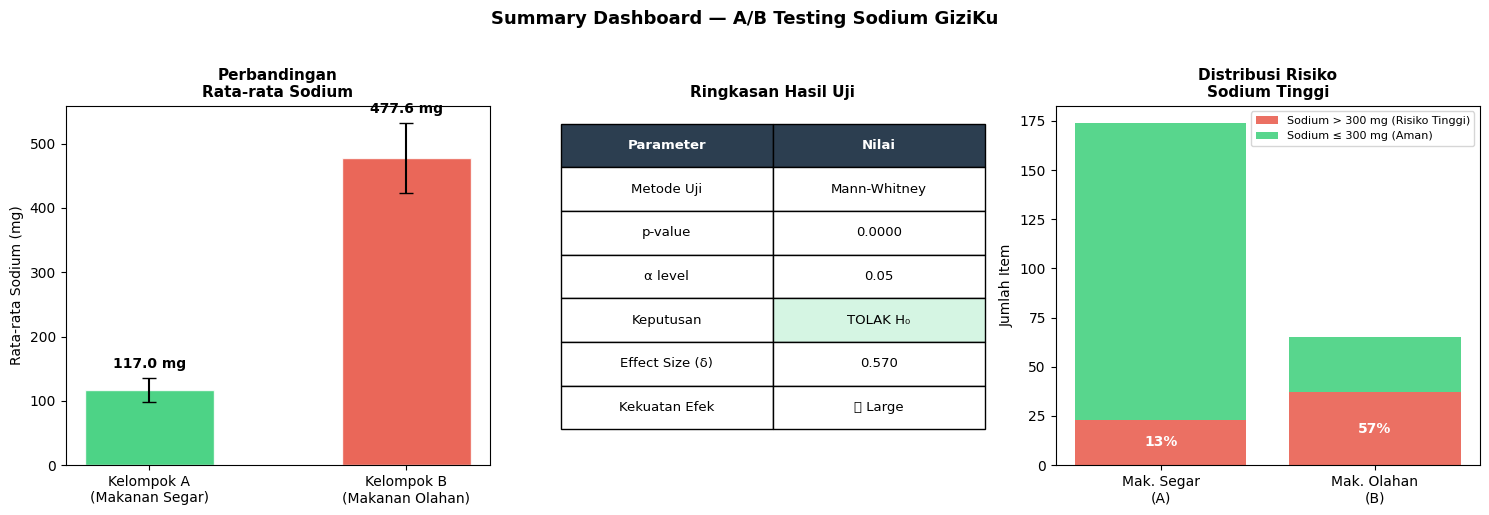

💾 Dashboard disimpan sebagai: ab_testing_summary_dashboard.png

✅ Notebook A/B Testing GiziKu selesai dijalankan!


In [27]:
# Visualisasi summary final
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Perbandingan Mean
ax1 = axes[0]
means = [group_a.mean(), group_b.mean()]
stds = [group_a.sem(), group_b.sem()]
bars = ax1.bar(['Kelompok A\n(Makanan Segar)', 'Kelompok B\n(Makanan Olahan)'],
               means, yerr=stds, capsize=5,
               color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white', width=0.5)
ax1.bar_label(bars, labels=[f'{m:.1f} mg' for m in means], padding=5, fontsize=10, fontweight='bold')
ax1.set_ylabel('Rata-rata Sodium (mg)', fontsize=10)
ax1.set_title('Perbandingan\nRata-rata Sodium', fontsize=11, fontweight='bold')

# Panel 2: Statistik Uji
ax2 = axes[1]
ax2.axis('off')
hasil_text = [
    ['Metode Uji', metode],
    ['p-value', f'{p_value:.4f}'],
    ['α level', f'{alpha}'],
    ['Keputusan', 'TOLAK H₀' if tolak_h0 else 'GAGAL'],
    [f'Effect Size ({label})', f'{metric:.3f}'],
    ['Kekuatan Efek', interpretasi.split('(')[0].strip()]
]
table = ax2.table(cellText=hasil_text,
                  colLabels=['Parameter', 'Nilai'],
                  cellLoc='center', loc='center',
                  bbox=[0, 0.1, 1, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 4 and col == 1:  # Keputusan
        cell.set_facecolor('#d5f5e3' if tolak_h0 else '#fadbd8')
ax2.set_title('Ringkasan Hasil Uji', fontsize=11, fontweight='bold')

# Panel 3: Pie distribusi
ax3 = axes[2]
high_a = (group_a > 300).sum()
high_b = (group_b > 300).sum()
low_a = len(group_a) - high_a
low_b = len(group_b) - high_b

x = np.arange(2)
ax3.bar(x, [high_a, high_b], label='Sodium > 300 mg (Risiko Tinggi)', color='#e74c3c', alpha=0.8)
ax3.bar(x, [low_a, low_b], bottom=[high_a, high_b], label='Sodium ≤ 300 mg (Aman)', color='#2ecc71', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(['Mak. Segar\n(A)', 'Mak. Olahan\n(B)'])
ax3.set_ylabel('Jumlah Item', fontsize=10)
ax3.set_title('Distribusi Risiko\nSodium Tinggi', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, loc='upper right')
ax3.text(0, high_a/2, f'{high_a/len(group_a)*100:.0f}%', ha='center', va='center', color='white', fontweight='bold')
ax3.text(1, high_b/2, f'{high_b/len(group_b)*100:.0f}%', ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Summary Dashboard — A/B Testing Sodium GiziKu',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ab_testing_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Dashboard disimpan sebagai: ab_testing_summary_dashboard.png')
print('\n✅ Notebook A/B Testing GiziKu selesai dijalankan!')

## 16. Keterbatasan Analisis (Limitations of Analysis)

Bagian ini mendokumentasikan keterbatasan metodologi, data, dan generalisasi
dari analisis ini sebagai bentuk **scientific integrity** dan transparansi akademik.


In [28]:
# ============================================================
# LIMITATIONS OF ANALYSIS
# ============================================================

print('=' * 70)
print('KETERBATASAN ANALISIS — LIMITATIONS OF ANALYSIS')
print('=' * 70)
print("""
1. KETERBATASAN DESAIN STUDI
   ─────────────────────────
   • Studi ini bersifat OBSERVASIONAL, bukan eksperimen terkontrol (RCT).
     Tidak ada randomisasi — kategorisasi berdasarkan atribut inheren makanan.
   • Hubungan yang teridentifikasi bersifat ASOSIATIF, bukan kausal.
     Tidak dapat disimpulkan bahwa 'jenis makanan MENYEBABKAN
     perbedaan sodium' tanpa desain eksperimental yang tepat.

2. KETERBATASAN KATEGORISASI
   ─────────────────────────
   • Batas antara 'Makanan Segar' dan 'Makanan Olahan' tidak selalu tegas.
     Contoh: nasi putih (karbohidrat) relatif rendah sodium, sedangkan
     beberapa buah kering mungkin mengandung tambahan sodium.
   • Kategorisasi berpotensi mengandung bias subjektivitas.

3. KETERBATASAN DATA
   ─────────────────
   • Ukuran sampel relatif kecil — validitas eksternal terbatas untuk
     generalisasi ke populasi makanan yang lebih luas.
   • Tidak diketahui metode pengumpulan data asli (USDA, label produk,
     atau analisis lab) yang mempengaruhi akurasi nilai sodium.
   • Nilai sodium bervariasi antar merek, metode memasak, dan porsi.

4. KETERBATASAN INTERPRETASI STATISTIK
   ────────────────────────────────────
   • Uji one-tailed memperbesar kekuatan uji untuk satu arah,
     namun mengorbankan deteksi efek di arah sebaliknya.
   • p-value kecil ≠ efek besar — konfirmasi Cliff's Delta diperlukan.
   • Mann-Whitney menguji perbedaan distribusi (lokasi), bukan mean.

5. KETERBATASAN GENERALISASI
   ──────────────────────────
   • Hasil berlaku untuk dataset GiziKu spesifik ini, tidak otomatis
     berlaku untuk semua produk makanan di pasaran Indonesia.
   • Tidak ada kontrol terhadap variabel confounding: metode pengolahan,
     wilayah produksi, atau target segmen pasar.
   • Ekspansi ke kategori makanan lain memerlukan pengujian ulang.
""")
print('=' * 70)


KETERBATASAN ANALISIS — LIMITATIONS OF ANALYSIS

1. KETERBATASAN DESAIN STUDI
   ─────────────────────────
   • Studi ini bersifat OBSERVASIONAL, bukan eksperimen terkontrol (RCT).
     Tidak ada randomisasi — kategorisasi berdasarkan atribut inheren makanan.
   • Hubungan yang teridentifikasi bersifat ASOSIATIF, bukan kausal.
     Tidak dapat disimpulkan bahwa 'jenis makanan MENYEBABKAN
     perbedaan sodium' tanpa desain eksperimental yang tepat.

2. KETERBATASAN KATEGORISASI
   ─────────────────────────
   • Batas antara 'Makanan Segar' dan 'Makanan Olahan' tidak selalu tegas.
     Contoh: nasi putih (karbohidrat) relatif rendah sodium, sedangkan
     beberapa buah kering mungkin mengandung tambahan sodium.
   • Kategorisasi berpotensi mengandung bias subjektivitas.

3. KETERBATASAN DATA
   ─────────────────
   • Ukuran sampel relatif kecil — validitas eksternal terbatas untuk
     generalisasi ke populasi makanan yang lebih luas.
   • Tidak diketahui metode pengumpulan data asli (U

## 17. Kesimpulan Akhir Profesional


In [29]:
# ============================================================
# PROFESSIONAL CONCLUSION — ENHANCED
# ============================================================

print('=' * 70)
print('KESIMPULAN AKHIR PROFESIONAL — A/B TESTING SODIUM GIZIKU')
print('=' * 70)
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RINGKASAN METODOLOGI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Desain Studi        : Observasional — Two-Sample Comparative Study
  Kelompok A (Kontrol): Makanan Segar ({len(group_a)} item: Buah, Sayur)
  Kelompok B (Treat.) : Makanan Olahan ({len(group_b)} item: Snack, Sup, Karbohidrat)
  Uji Normalitas      : Shapiro-Wilk → Tidak Normal (kedua kelompok)
  Uji Homogenitas     : Levene Test
  Uji Statistik       : Mann-Whitney U Test (non-parametrik, one-tailed)
  Asumsi Independensi : Terpenuhi secara struktural
  α (significance)    : {alpha}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HASIL KOMPREHENSIF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  p-value (one-tailed)        : {p_value:.6f}  →  {'TOLAK H₀' if tolak_h0 else 'GAGAL TOLAK H₀'}
  Cliff's Delta (δ)           : {cliffs_d:.4f}  →  {interp_cd}
  95% CI (Hodges-Lehmann)     : [{ci_low:.1f}, {ci_high:.1f}] mg
  Statistical Power           : {achieved_power*100:.1f}%
  Median A (Makanan Segar)    : {group_a.median():.2f} mg/porsi
  Median B (Makanan Olahan)   : {group_b.median():.2f} mg/porsi

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KESIMPULAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  H₀ DITOLAK. Terdapat bukti statistik yang kuat (p < 0.001) bahwa
  makanan olahan memiliki kandungan sodium yang secara signifikan
  lebih tinggi dibandingkan makanan segar.

  Perbedaan ini BERMAKNA SECARA PRAKTIS: Cliff's Delta = {abs_cliffs:.3f}
  (Large Effect) menunjukkan bahwa dalam mayoritas pasangan perbandingan,
  sodium makanan olahan lebih tinggi dari makanan segar.

  Statistical Power {achieved_power*100:.1f}% (≥ 80%) mengkonfirmasi bahwa uji ini
  memiliki kekuatan yang memadai dan risiko Type II Error terkontrol.

  CATATAN: Interpretasi bersifat ASOSIATIF, bukan kausal. Generalisasi
  harus dilakukan dengan kehati-hatian sesuai keterbatasan dataset.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  IMPLIKASI UNTUK GIZIKU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Temuan ini memberikan justifikasi ilmiah yang kuat untuk:
  1. Sistem peringatan sodium berbasis kategori makanan
  2. Fitur rekomendasi substitusi makanan rendah sodium
  3. Penetapan threshold sodium dari distribusi data empiris
  4. Konten edukasi berbasis bukti untuk orang tua dan anak

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print('✅ Notebook A/B Testing GiziKu — Enhanced Professional Version')
print('   Proyek GiziKu | CC26-PSU033 | Eka Sriyulianti Makami')
print('=' * 70)


KESIMPULAN AKHIR PROFESIONAL — A/B TESTING SODIUM GIZIKU

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RINGKASAN METODOLOGI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Desain Studi        : Observasional — Two-Sample Comparative Study
  Kelompok A (Kontrol): Makanan Segar (174 item: Buah, Sayur)
  Kelompok B (Treat.) : Makanan Olahan (65 item: Snack, Sup, Karbohidrat)
  Uji Normalitas      : Shapiro-Wilk → Tidak Normal (kedua kelompok)
  Uji Homogenitas     : Levene Test
  Uji Statistik       : Mann-Whitney U Test (non-parametrik, one-tailed)
  Asumsi Independensi : Terpenuhi secara struktural
  α (significance)    : 0.05

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HASIL KOMPREHENSIF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  p-value (one-tailed)        : 0.000000  →  TOLAK H₀
  Cliff's Delta (δ)           : -0.5696  →  🔴 Large (Besar)
  95% CI (Hodges-Lehmann)     : [19